# Grad-CAM Visualization: What Does the Classifier Learn?

This notebook uses Gradient-weighted Class Activation Mapping (Grad-CAM) to visualize which regions of the images the classifier focuses on when distinguishing synthetic from original mammograms.

## Goal:
Understand WHAT patterns/features the classifier uses to achieve 100% accuracy.

## Output:
- Heatmaps showing important regions
- Side-by-side comparisons
- Analysis of learned patterns


In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import tensorflow as tf
from tensorflow import keras
import glob
import random

# Add parent directory to path
parent_dir = '/home/a.kanamarlapudi001/projects/omama-proj/_EXPERIMENTS/SYNTHETIC/Avanith'
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import classifier

print("Libraries loaded successfully!")


2025-10-30 20:31:51.654156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761870711.781790 3597792 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761870711.832715 3597792 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761870712.110555 3597792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761870712.110578 3597792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761870712.110580 3597792 computation_placer.cc:177] computation placer alr

Libraries loaded successfully!


## Load Trained Model


In [2]:
# Load the trained model from Experiment 2 (normalized)
MODEL_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5'
model = keras.models.load_model(MODEL_PATH)

print(f"Model loaded from: {MODEL_PATH}")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")


I0000 00:00:1761870717.756781 3597792 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:07:00.0, compute capability: 8.0


Model loaded from: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5
Model input shape: (None, 512, 512, 1)
Model output shape: (None, 2)


## Grad-CAM Implementation


In [3]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a given image.
    
    Args:
        img_array: Input image (1, H, W, 1)
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        pred_index: Class index to visualize (None = predicted class)
    
    Returns:
        heatmap: Grad-CAM heatmap
    """
    # Create model that outputs both predictions and last conv layer
    grad_model = keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute gradient of predicted class with respect to last conv layer
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Gradient of class with respect to output feature map
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Mean intensity of gradient over specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel by importance
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads.numpy()
    conv_outputs = conv_outputs.numpy()
    
    for i in range(pooled_grads.shape[0]):
        conv_outputs[:, :, i] *= pooled_grads[i]
    
    # Average across all channels
    heatmap = np.mean(conv_outputs, axis=-1)
    
    # Normalize to [0, 1]
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    
    return heatmap

# Find the last convolutional layer name
last_conv_layer = None
for layer in reversed(model.layers):
    if 'conv' in layer.name:
        last_conv_layer = layer.name
        break

print(f"Using layer for Grad-CAM: {last_conv_layer}")


Using layer for Grad-CAM: conv5


## Load Sample Images


In [4]:
# Paths
SYNTHETIC_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/full_synthetic_resized/'
ORIGINAL_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/full_original_method3/'

# Load 20 random samples from each
syn_files = sorted(glob.glob(SYNTHETIC_PATH + '*.png'))
orig_files = sorted(glob.glob(ORIGINAL_PATH + '*.png'))

random.seed(42)
selected_syn = random.sample(syn_files, 20)
selected_orig = random.sample(orig_files, 20)

print(f"Selected 20 synthetic images")
print(f"Selected 20 original images")


Selected 20 synthetic images
Selected 20 original images


## Generate Grad-CAM for Synthetic Images


Generating Grad-CAM for synthetic images...


/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input']]
Received: inputs=Tensor(shape=(1, 512, 512, 1))
  warnings.warn(msg)
I0000 00:00:1761870721.439939 3597792 cuda_dnn.cc:529] Loaded cuDNN version 90300
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


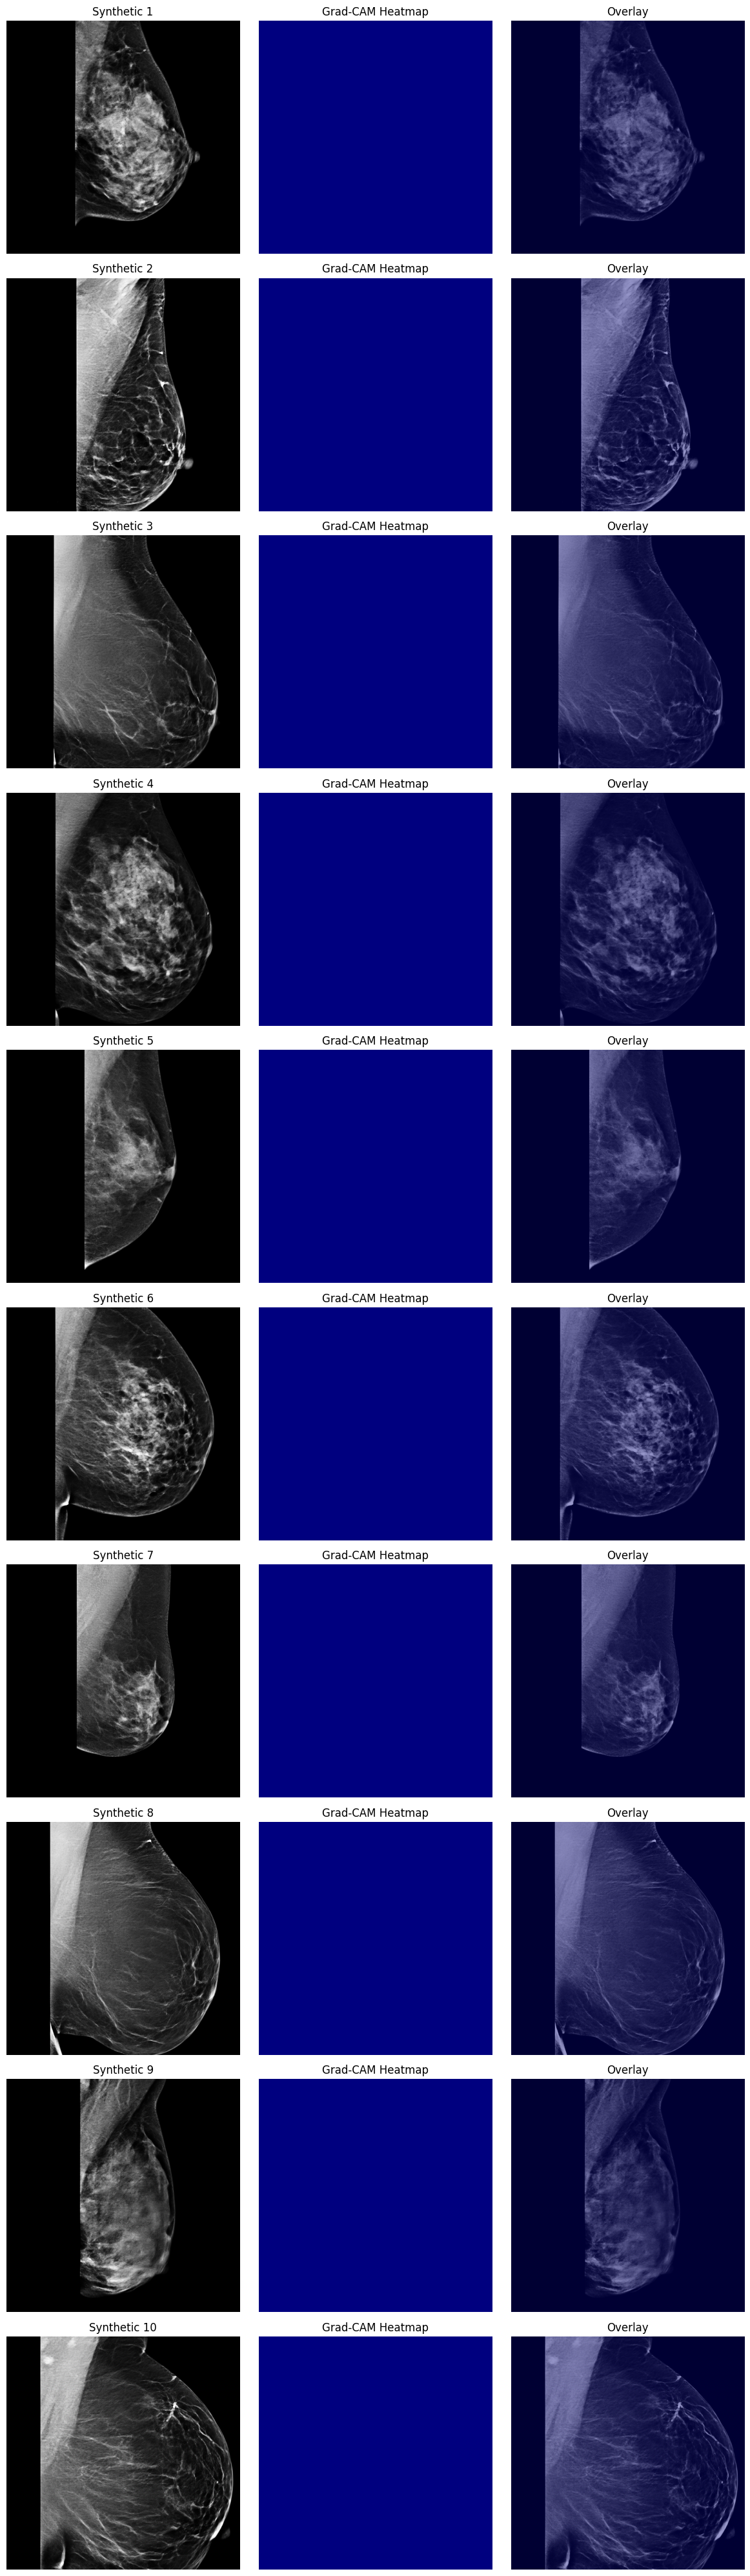

Synthetic Grad-CAM visualization complete!


In [5]:
# Visualize Grad-CAM for 10 synthetic images
fig, axes = plt.subplots(10, 3, figsize=(12, 40))

print("Generating Grad-CAM for synthetic images...")

for i in range(10):
    # Load and preprocess image (same as NormalizedDataGenerator)
    img_path = selected_syn[i]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    
    # Normalize (same as training)
    mean = img.mean()
    std = img.std()
    if std > 0:
        img_normalized = (img - mean) / std
    else:
        img_normalized = img - mean
    
    # Prepare for model
    img_array = np.expand_dims(np.expand_dims(img_normalized, axis=-1), axis=0)
    
    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer, pred_index=0)
    
    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap, (512, 512))
    
    # Original image
    axes[i, 0].imshow(cv2.imread(img_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    axes[i, 0].set_title(f'Synthetic {i+1}')
    axes[i, 0].axis('off')
    
    # Heatmap
    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap')
    axes[i, 1].axis('off')
    
    # Overlay
    img_display = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(img_display, cv2.COLOR_GRAY2BGR), 0.6, 
                               heatmap_colored, 0.4, 0)
    axes[i, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/gradcam_synthetic.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Synthetic Grad-CAM visualization complete!")


## Generate Grad-CAM for Original Images


Generating Grad-CAM for original images...


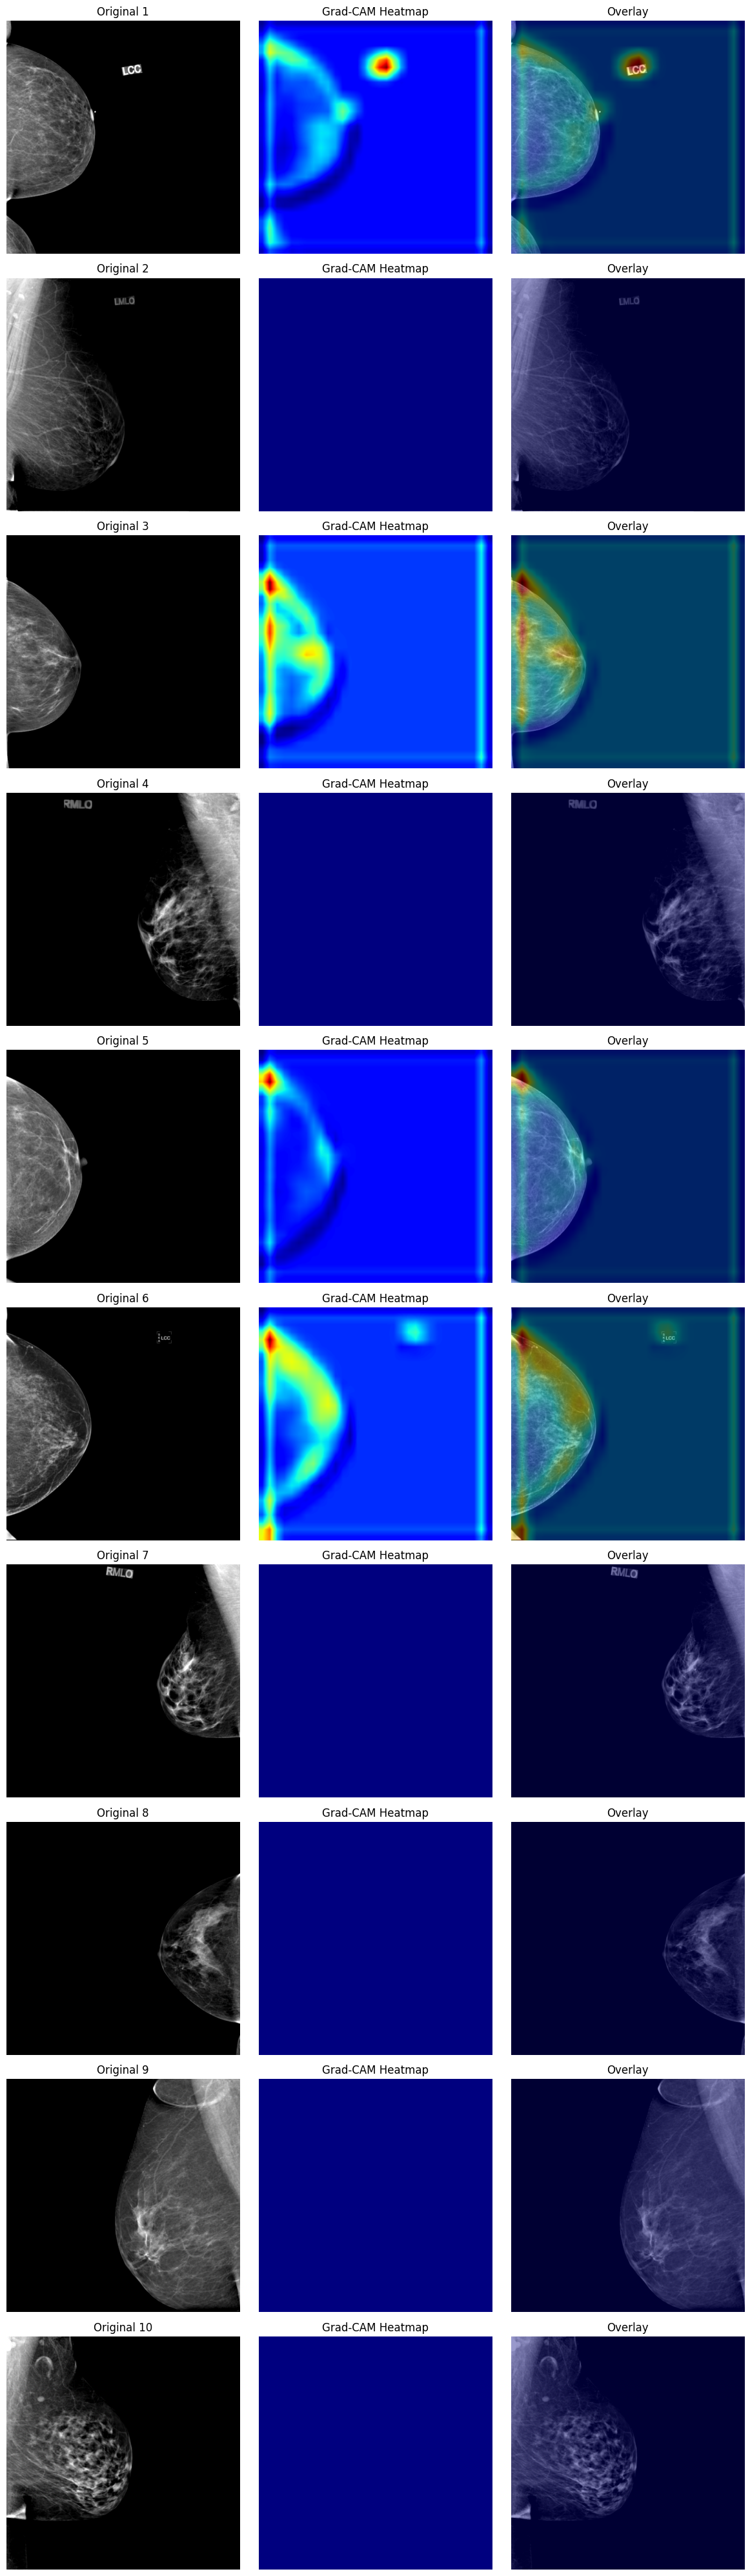

Original Grad-CAM visualization complete!


In [6]:
# Visualize Grad-CAM for 10 original images
fig, axes = plt.subplots(10, 3, figsize=(12, 40))

print("Generating Grad-CAM for original images...")

for i in range(10):
    # Load and preprocess image
    img_path = selected_orig[i]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    
    # Normalize
    mean = img.mean()
    std = img.std()
    if std > 0:
        img_normalized = (img - mean) / std
    else:
        img_normalized = img - mean
    
    # Prepare for model
    img_array = np.expand_dims(np.expand_dims(img_normalized, axis=-1), axis=0)
    
    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer, pred_index=1)
    
    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (512, 512))
    
    # Original image
    axes[i, 0].imshow(cv2.imread(img_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')
    
    # Heatmap
    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap')
    axes[i, 1].axis('off')
    
    # Overlay
    img_display = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(img_display, cv2.COLOR_GRAY2BGR), 0.6, 
                               heatmap_colored, 0.4, 0)
    axes[i, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/gradcam_original.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Original Grad-CAM visualization complete!")


## Interpretation

Red/yellow regions show where the classifier focuses to make decisions.
This reveals the patterns that distinguish synthetic from original.
